In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def erro2(x,y,dx):
  err = np.sqrt(np.sum((x-y)**2)*dx)
  return err

def reestrut(n,x_i,x):
  k = len(x_i)
  indices = (n)*np.arange(k)
  x_new = x[indices]
  return x_new

In [ ]:
class Dominio_tempo:
  '''esse dominio temporal'''
  def __init__(self,t_i=0,t_f=1,k=0.01):
    self.t_i = t_i
    self.t_f = t_f
    self.k = k

In [ ]:
class Dominio_espaco:
  '''esse dominio espacial'''
  def __init__(self,a=0,b=1,h=0.01):
    self.a = a
    self.b = b
    self.h = h

In [ ]:
class Testes:
  def __init__(self,ini = 1,spec = 0, dom_esp = Dominio_espaco(), dom_tem = Dominio_tempo()):
    self.ini  = ini
    '''ini = 0 ==> EDO linear
       ini = 1 ==> EDO Não linear Não stiff
       ini = 2 ==> EDO Não linear stiff
       ini = 3 ==> EDO Não linear stiff oscilatório'''
    self.spec = spec
    '''spec = 0 ==> não se usa método espectral
       spec = 1 ==> advecção velocidade constante
       spec = 2 ==> advecção velocidade variável
       spec = 3 ==> burgers'''
    self.dom_esp  = dom_esp
    self.dom_tem  = dom_tem



  def cond_inicial(self,x = 0):
    if self.ini == 0:
      x_0 = np.array([1])
      return x_0
    elif self.ini == 1:
      x_0 = np.array([1])
      return x_0
    elif self.ini == 2:
      x_0 = np.array([1])
      return x_0
    elif self.ini == 3:
      x_0 = np.array([2])
      return x_0
    elif self.ini == 4 and self.spec == 1:
      u_0 = np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
      return u_0
    elif self.ini == 4 and self.spec == 2:
      u_0 = np.exp(np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a)))
      return u_0
    elif self.ini == 5 and self.spec == 3:
      u_0 = np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
      return u_0
    elif self.ini == 6 and self.spec == 3:
      u_0 = np.sin(2*np.pi*x/(self.dom_esp.b - self.dom_esp.a))
      return u_0

  def perf_vel(self,x = 0):
    if self.ini == 4 and (self.spec == 1 or self.spec == 2):
      c = np.sqrt(2)*np.ones_like(x)
      return c


  def func_exata(self,t):
    if self.ini == 0:
      return np.exp(2*t)
    elif self.ini == 1:
      return np.exp(2*t)*t + np.exp(2*t)
    elif self.ini == 2:
      return (1+(1j/1001))*np.exp(-1000j*t) - 1j*np.exp(1j*t)/1001
    elif self.ini == 3:
      return np.cos(t) + np.exp(-1000*t)


  def test_normal(self,x:np.ndarray,t:float):
    '''Essa função tem como entradas os parametros:
    x --- a posição no tempo t
    t --- tempo'''
    if self.ini == 0: #nesse caso vamos testar que para o caso puramente linear Euler_Exp_explicito é exato
      A = np.diag(np.array([2]))
      y = np.dot(A,x)
      return y
    elif self.ini == 1: #x(t) = exp(2t)*t + 2*exp(2t)
      A = np.diag(np.array([2]))
      y = np.dot(A,x) + np.exp(2*t)
      return y
    elif self.ini == 2:  #x(t) = -(100/10001)cos(10t)-(1/10001)sin(10t) + (10101/10001)*exp(t)
      A = np.diag(np.array([-1000j]))
      y = np.dot(A,x) + np.exp(1j*t)
      return y
    elif self.ini == 3:  #x(t) = cos(t) + exp(-1000t)
      A = np.diag(np.array([-1000]))
      y = np.dot(A,x) - (-1000)*np.cos(t) - np.sin(t)
      return y
    elif self.ini == 4 and (self.spec == 1 or self.spec == 2):
      A = self.test_exp_lin(x = x)
      y = A*x + self.test_exp_nlin(x,t)
      return y
    elif self.ini == 5 and self.spec == 3:
      A = self.test_exp_lin(x = x)
      y = A*x + self.test_exp_nlin(x,t)
      return y
    elif self.ini == 6 and self.spec == 3:
      A = self.test_exp_lin(x = x)
      y = A*x + self.test_exp_nlin(x,t)
      return y

  def test_exp_lin(self,x):
    if self.ini == 0:
      A = (np.array([2]))
      return A
    elif self.ini == 1:
      A = (np.array([2]))
      return A
    elif self.ini == 2:
      A = (np.array([-1000j]))
      return A
    elif self.ini == 3:
      A = (np.array([-1000]))
      return A
    elif self.ini == 4 and  (self.spec == 1 or self.spec == 2):
      N = int((len(x)//2))

      k = np.zeros(len(x), dtype = int)
      k[1:N+1] = np.linspace(1, N, N, endpoint = True)
      k[N+1:] = -np.flip(k[1:N+1])

      c = self.perf_vel(x = x)

      A = 2*np.pi*c*k*1j

      return A
    elif self.ini == 5 and self.spec == 3:
      N = int((len(x)//2))
      k = np.zeros(len(x), dtype = int)
      k[1:N+1] = np.linspace(1, N, N, endpoint = True)
      k[N+1:] = -np.flip(k[1:N+1])
      c = np.zeros_like(x)

      A = c*1j

      return A

    elif self.ini == 6 and self.spec == 3:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])


      A = 0.01*(2*np.pi*k*1j)**2

      return A



  def test_exp_nlin(self,x,t):
    if self.ini == 0:
      y = 0
      return y
    elif self.ini == 1:
      y =  np.exp(2*t)
      return y
    elif self.ini == 2:
      y = np.exp(1j*t)
      return y
    elif self.ini ==3:
      y = -(-1000)*np.cos(t) - np.sin(t)
      return y
    elif self.ini == 4 and (self.spec == 1 or self.spec == 2):
      N = len(x)
      A = np.zeros(N,dtype=complex)

      return A
    elif self.ini == 5 and self.spec == 3:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral


      x_deriv = 2*np.pi*k_redef*1j*x_redef # definimos a derivada no espaço espectral

      w_real = -IFFT(x_redef)*IFFT(x_deriv)
      A,k = FFT(w_real)

      return A

    elif self.ini == 6 and self.spec == 3:
      M_line = len(x)
      N_line = int((M_line-1)/2)

      k = np.zeros(len(x), dtype = int)
      k[1:N_line+1] = np.linspace(1, N_line, N_line, endpoint = True)
      k[N_line+1:] = -np.flip(k[1:N_line+1])

      x_redef,k_redef = redef_f(f = np.copy(x), k = k,N = N_line) # redefinir no espaço espectral

      x_new = np.arange(self.dom_esp.a,self.dom_esp.b,1/len(x))

      x_deriv = 2*np.pi*k_redef*1j*x_redef # definimos a derivada no espaço espectral

      w_real = -IFFT(x_redef)*IFFT(x_deriv) - 1*IFFT(x)

      A,k = FFT(w_real)

      return A

#Agora, escreveremos os métodos usuais explícitos

In [ ]:
def Euler_Explicito(x,a,b,h,dom,teste,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    x_total[i+1] = x_total[i] + h*teste.test_normal(x_total[i],i*h)
  return x_total

def RungeKutta22(x,a,b,h,dom,teste,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    k1 = h*teste.test_normal(x_total[i],i*h)
    k2 = h*teste.test_normal(x_total[i]+k1/2,(i+0.5)*h)
    x_total[i+1] = x_total[i] + k2
  return x_total

def RungeKutta44(x,a,b,h,dom,teste,impli = False,tol = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    k1 = h*teste.test_normal(x_total[i],i*h)
    k2 = h*teste.test_normal(x_total[i]+k1/2,(i+0.5)*h)
    k3 = h*teste.test_normal(x_total[i]+k2/2,(i+0.5)*h)
    k4 = h*teste.test_normal(x_total[i]+k3,(i+1)*h)
    x_total[i+1] = x_total[i] + (k1 + 2*k2 + 2*k3 + k4)/6
  return x_total

#Escreveremos os métodos usuais implícito





In [ ]:
def Euler_Implicito(x,a,b,h,dom,teste,impli = True,TOL = 10**(-3)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  for i in range(int((b-a)/h)):
    tol = 1
    x_new1 = np.copy(x_total[i])
    while tol >= TOL:
      x_new2 = x_total[i] + h*teste.test_normal(x_new1,(i+1)*h)
      tol = np.sum(np.abs(x_new2 - x_new1))
      x_new1 = np.copy(x_new2)
    x_total[i+1] = x_new1
  return x_total

#Aqui, escreveremos os integradores exponenciais ETD




In [ ]:
def ExpA(h,M):
  '''essa calculadora de exponencial de matriz só é válida para matriz diagonal
  sendo M --- diagonal da matriz que queremos encontrar a exponencial'''
  EA = np.exp(h*M)
  return EA



def phi_1(h, M):
    """
    Calcula phi_1(h,M) de forma vetorizada
    usando índices, sem for.
    """
    M = np.asarray(M, dtype=complex)
    n = M.shape[0]

    # vetor de índices
    indices = np.arange(n)

    # caso trivial
    if np.allclose(M, 0) or h == 0:
        return np.ones_like(M)

    # caso h muito pequeno
    if h <= 1e-8:
        return 1 + 0.5 * h * M

    # caso geral
    Exp = ExpA(h, M)     # se for só exp elementwise, pode usar np.exp(h*M)
    num = Exp - 1.0

    phi = np.empty_like(M)

    # índices válidos (M ≠ 0)
    mask = M != 0
    phi[indices[mask]] = num[indices[mask]] / (h * M[indices[mask]])

    # índices inválidos (M = 0) → limite = 1
    phi[indices[~mask]] = 1.0

    return phi

def phi_2(h, M):
    """
    Calcula phi_2(h,M) de forma vetorizada
    usando índices, sem for.
    """
    M = np.asarray(M, dtype=complex)
    n = M.shape[0]

    # vetor de índices
    indices = np.arange(n)

    # caso trivial
    if np.allclose(M, 0) or h == 0:
        return 0.5 * np.ones_like(M)

    # caso h muito pequeno
    if h <= 1e-8:
        return 0.5 + (1/6) * h * M

    # caso geral
    Exp = ExpA(h, M)   # se for só elementwise, pode ser np.exp(h*M)
    num = Exp - 1.0 - h*M

    phi = np.empty_like(M)

    # índices válidos (M ≠ 0)
    mask = M != 0
    phi[indices[mask]] = num[indices[mask]] / ((h*M[indices[mask]])**2)

    # índices inválidos (M = 0) → limite = 0.5
    phi[indices[~mask]] = 0.5

    return phi



def Euler_Exp_Explicito(x,a,b,h,dom,teste,impli = True,TOL = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função não linear
  M --- Parte linear'''
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  x_old = np.copy(x)
  x_new = np.zeros_like(x)
  #esta variavel exp_lin e phi_lin são para que o exponencial não seja calculado para toda iterada
  if teste.ini == 0 or (teste.ini == 4 ):
    for i in range(int((b-a)/h)):
      x_total[i+1] = ExpA((i+1)*h,teste.test_exp_lin(x=x))*x_total[0]
  else:
    exp_lin = ExpA(h,teste.test_exp_lin(x=x))
    phi_lin = phi_1(h,teste.test_exp_lin(x=x))


    for i in range(int((b-a)/h)):
      x_total[i+1] = exp_lin*x_total[i] + h*phi_lin*teste.test_exp_nlin(x_total[i],i*h)
      x_old = np.copy(x_new)
  return x_total




#Vamos aqui fazer um método de segunda ordem.

Sendo o método RK2_Exp_Explicito1 que o passo intermediário é feito no limite superior do intervalo dt.

Agora, o método RK2_Exp_Explicito2 possui o passo intermediário feito no ponto médio do intervalo.

In [ ]:
def RK2_Exp_Explicito1(x,a,b,h,dom,teste,impli = True,TOL = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função não linear
  M --- Parte linear'''
  c_2 = 1
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  if teste.ini == 0 or (teste.ini == 4 ):
    for i in range(int((b-a)/h)):
      x_total[i+1] = ExpA((i+1)*h,teste.test_exp_lin(x=x))*x_total[0]
  #esta variavel exp_lin e phi_lin são para que o exponencial não seja calculado para toda iterada
  else:
    exp_lin = ExpA(h,teste.test_exp_lin(x=x))
    exp_lin2 = ExpA(c_2*h,teste.test_exp_lin(x=x))#nesse programa consideramos c_2 = 1/2
    phi1_lin = phi_1(h,teste.test_exp_lin(x=x))
    phi1_lin2 = phi_1(c_2*h,teste.test_exp_lin(x=x))
    phi2_lin = phi_2(h,teste.test_exp_lin(x=x))
    for i in range(int((b-a)/h)):
      k1 = exp_lin2*x_total[i] + h*c_2*phi1_lin2*teste.test_exp_nlin(x_total[i],i*h)
      #faremos essa conta por partes
      lin = exp_lin*x_total[i]

      b1 = (phi1_lin - (1/c_2)*phi2_lin)*teste.test_exp_nlin(x_total[i],i*h)

      b2 = (1/c_2)*phi2_lin*teste.test_exp_nlin(k1,(i+c_2)*h)

      x_total[i+1] = lin + h*b1 + h*b2
  return x_total


In [ ]:
def RK2_Exp_Explicito2(x,a,b,h,dom,teste,impli = True,TOL = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função não linear
  M --- Parte linear'''
  c_2 = 1/2
  x_total = np.zeros([int((b-a)/h)+1,len(x)],dtype=complex)
  x_total[0] = np.copy(x)
  if teste.ini == 0 or (teste.ini == 4) :
    for i in range(int((b-a)/h)):
      x_total[i+1] = ExpA((i+1)*h,teste.test_exp_lin(x=x))*x_total[0]
  #esta variavel exp_lin e phi_lin são para que o exponencial não seja calculado para toda iterada
  else:
    exp_lin = ExpA(h,teste.test_exp_lin(x=x))
    exp_lin2 = ExpA(c_2*h,teste.test_exp_lin(x=x))#nesse programa consideramos c_2 = 1/2
    phi1_lin = phi_1(h,teste.test_exp_lin(x=x))
    phi1_lin2 = phi_1(c_2*h,teste.test_exp_lin(x=x))
    phi2_lin = phi_2(h,teste.test_exp_lin(x=x))
    for i in range(int((b-a)/h)):
      k1 = exp_lin2*x_total[i] + h*c_2*phi1_lin2*teste.test_exp_nlin(x_total[i],i*h)
      #faremos essa conta por partes
      lin = exp_lin*x_total[i]

      b1 = (phi1_lin - (1/c_2)*phi2_lin)*teste.test_exp_nlin(x_total[i],i*h)

      b2 = (1/c_2)*phi2_lin*teste.test_exp_nlin(k1,(i+c_2)*h)

      x_total[i+1] = lin + h*b1 + h*b2
  return x_total


#Aqui, escreveremos os integradores exponenciais IF

pela simplicidade usaremos os métodos IF-euler explícito e os métodos de Lawson para Runge Kutta de primeira a segunda ordem.


In [ ]:
def IFEuler_Explicito(x,a,b,h,dom,teste,impli = False,TOL = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada'''
  x_total = np.zeros([int((b-a)/h)+1,len(x)])
  x_total[0] = np.copy(x)
  exp_lin = ExpA(h,teste.test_exp_lin())
  for i in range(int((b-a)/h)):
    x_total[i+1] = np.dot(exp_lin, x_total[i] + h*teste.test_exp_nlin(x_total[i],i*h))
  return x_total

In [ ]:
def Lawson_2ordem_a(x,a,b,h,dom,teste,impli = False,TOL = 10**(-5)):
  '''Essa função tem como entradas os parametros:
  x --- condição inicial
  a --- ponto inicial
  b --- ponto final
  h --- passo no tempo
  f --- função a ser aplicada
  a_{12} = 1/2
  '''
  x_total = np.zeros([int((b-a)/h)+1,len(x)])
  x_total[0] = np.copy(x)
  exp_lin = ExpA(h,teste.test_exp_lin())
  exp_lin2 = ExpA(0.5*h,teste.test_exp_lin())

  for i in range(int((b-a)/h)):

    k1 = teste.test_exp_nlin(x_total[i],i*h)

    k2 = teste.test_exp_nlin(np.dot(exp_lin2,x_total[i] + h*k1/2),(i+0.5)*h)

    x_total[i+1] = np.dot(exp_lin, x_total[i]) + h*np.dot(exp_lin2,k2)
  return x_total

#TESTES

##--Teste de convergência

Para esse teste, serão somente analisados problemas de uma varável para tornar mais simples a análise.

In [ ]:
dom = Dominio_tempo(t_i=0,t_f=1,k=0.1)
teste = Testes(ini = 2,spec = 0, dom_tem = dom)

In [ ]:
M = 15
valx1 = np.zeros(M,dtype=complex)
valx2 = np.zeros(M,dtype=complex)
valx3 = np.zeros(M,dtype=complex)
valx4 = np.zeros(M,dtype=complex)
valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
t = np.zeros(M)

for i in range(M):
  t[i] = dom.k*0.5**(i)
  x1 = Euler_Explicito(teste.cond_inicial(),dom.t_i,dom.t_f,(dom.k)/(2**i),dom,teste)
  valx1[i] = x1[-1]
  x2 = RungeKutta22(teste.cond_inicial(),dom.t_i,dom.t_f,(dom.k)/(2**i),dom,teste)
  valx2[i] = x2[-1]
  x3 = Euler_Exp_Explicito(teste.cond_inicial(),dom.t_i,dom.t_f,(dom.k)/(2**i),dom,teste)
  valx3[i] = x3[-1]
  x4 = RK2_Exp_Explicito1(teste.cond_inicial(),dom.t_i,dom.t_f,(dom.k)/(2**i),dom,teste)
  valx4[i] = x4[-1]
  x5 = RK2_Exp_Explicito2(teste.cond_inicial(),dom.t_i,dom.t_f,(dom.k)/(2**i),dom,teste)
  valx5[i] = x5[-1]
  valex[i] = teste.func_exata(1)


ordx1 = np.log2((valx1[1:-1]-valex[1:-1])/(valx1[0:-2]-valex[0:-2]))
ordx2 = np.log2((valx2[1:-1]-valex[1:-1])/(valx2[0:-2]-valex[0:-2]))
ordx3 = np.log2((valx3[1:-1]-valex[1:-1])/(valx3[0:-2]-valex[0:-2]))
ordx4 = np.log2((valx4[1:-1]-valex[1:-1])/(valx4[0:-2]-valex[0:-2]))
ordx5 = np.log2((valx5[1:-1]-valex[1:-1])/(valx5[0:-2]-valex[0:-2]))

/tmp/ipykernel_10235/2196945741.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  valx1[i] = x1[-1]
/tmp/ipykernel_10235/2196945741.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  valx2[i] = x2[-1]
/tmp/ipykernel_10235/2196945741.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  valx3[i] = x3[-1]
/tmp/ipykernel_10235/2196945741.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you 

KeyboardInterrupt: 

In [ ]:
plt.plot(t[:],abs(np.real(valx1-valex)),'-o',label = 'Euler explícito')
plt.plot(t[:],abs(np.real(valx2-valex)),'-o',label = 'Runge Kutta 22')
plt.plot(t[:],abs(np.real(valx3-valex)),'-o',label = 'ETDRK1')
plt.plot(t[:],abs(np.real(valx4-valex)),'-o',label = 'ETDRK2-tr')
plt.plot(t[:],abs(np.real(valx5-valex)),'-o', label = 'ETDRK2-pm ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()
plt.title('Comportamento do Erro - Teste não-linear e stiff ')
plt.xlabel('Passo')
plt.ylabel('Erro')
#plt.ylim(10**(-16),1)
plt.xscale('log')
plt.yscale('log')

In [ ]:
plt.plot(t[2:],ordx1,'-o',label = 'Euler explícito')
plt.plot(t[2:],ordx2,'-o',label = 'Runge Kutta 44')
plt.plot(t[2:],ordx3,'-o',label = 'ETDRK1')
plt.plot(t[2:],ordx4,'-o',label = 'ETD1RK2 ')
plt.plot(t[2:],ordx5,'-o', label = 'ETD2RK2 ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()
plt.title( 'Ordem de convergência')
plt.xlabel('Passo')
plt.ylabel('Ordem')
plt.xscale( 'log')


No gráfico de Ordem de convergência ETD1RK2 o passo é o runge kutta exponencial com passo intermediário no ponto final e ETD2RK2 o passo é o runge kutta exponencial com passo intermediário no ponto médio

##--Teste construção de gráficos

---




In [ ]:
dom = Dominio_tempo(t_i=0,t_f=1,k=0.1)
teste = Testes(ini = 1,dom_tem = dom)

In [ ]:
t = np.linspace(dom.t_i,dom.t_f, int((dom.t_f-dom.t_i)/dom.k)+1)


#x1 = Euler_Explicito(teste.cond_inicial(),dom.a,dom.b,dom.h,dom,teste)
#x2 = Euler_Implicito(teste.cond_inicial(),dom.a,dom.b,dom.h,dom,teste)
x2 = RungeKutta44(teste.cond_inicial(),dom.t_i,dom.t_f,dom.k,dom,teste)
x3 = Euler_Exp_Explicito(teste.cond_inicial(),dom.t_i,dom.t_f,dom.k,dom,teste)
x4 = RK2_Exp_Explicito2(teste.cond_inicial(),dom.t_i,dom.t_f,dom.k,dom,teste)
xex = teste.func_exata(t)

print(np.exp(0.1))

In [ ]:
#plt.plot(t,x1[:,0],label = 'Euler_explicito')
plt.plot(t,x2[:,0],label = 'RK44')
plt.plot(t,x3[:,0],label = 'ETD1RK')
plt.plot(t,x4[:,0],label = 'ETD2RK2')
plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()
plt.ylim(0,5)


#Equação de Advecção

In [ ]:
temp = Dominio_tempo(t_i=0,t_f=1,k=0.01)
espaco = Dominio_espaco(a=0,b = 1,h = 1/101)
teste = Testes(ini = 4,spec = 2,dom_esp = espaco,dom_tem = temp)

In [ ]:
x = np.arange(espaco.a,espaco.b,espaco.h) # espaço que vamos trabalhar

x_0 = teste.cond_inicial(x = x) # condição inicial
x_ex = teste.cond_inicial(x = x+np.sqrt(2)*temp.t_f)

f = np.fft.fft(x_0) #transformada de fourier da condição inicial

x_f = Euler_Exp_Explicito(x = f,a = temp.t_i,b = temp.t_f,h = temp.k,dom = temp,teste = teste) # evolução temporal


invf = np.fft.ifft(x_f[-1]) # volta para o espaço físico

plt.plot(x,np.real(invf),color = 'g')
plt.plot(x,x_0)
plt.plot(x,x_ex)
plt.show()





In [ ]:
def advect(func, tempo,espace , teste ):
  x = np.arange(espace.a,espace.b,espace.h)

  x_0 = np.copy(teste.cond_inicial(x = x))

  f = np.fft.fft(x_0)

  x_f = func(x = f,a = tempo.t_i,b = tempo.t_f,h = tempo.k,dom = temp,teste = teste)

  invf = np.fft.ifft(x_f[-1])
  return invf

In [ ]:
M = 10
valx1 = np.zeros(M,dtype=complex)
valx2 = np.zeros(M,dtype=complex)
valx3 = np.zeros(M,dtype=complex)
valx4 = np.zeros(M,dtype=complex)
valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
t = np.zeros(M)


for i in range(M):
  temp = Dominio_tempo(t_i=0,t_f=1,k=0.01*2**(-i))
  espaco = Dominio_espaco(a=0,b = 1,h = 1/(10*2*2 + 1))
  teste = Testes(ini = 4,spec = 2,dom_esp = espaco,dom_tem = temp)
  x = np.arange(espaco.a,espaco.b,espaco.h)

  t[i] = temp.k
  x1 = advect(Euler_Explicito,tempo = temp,espace=espaco,teste = teste)
  x2 = advect(RungeKutta22,tempo = temp,espace=espaco,teste = teste)
  x3 = advect(func = Euler_Exp_Explicito,tempo = temp,espace=espaco,teste = teste)
  x4 = advect(func = RK2_Exp_Explicito1,tempo = temp,espace=espaco,teste = teste)
  x5 = advect(func = RK2_Exp_Explicito2,tempo = temp,espace=espaco,teste = teste)

  x_exact = teste.cond_inicial(x = (x+np.sqrt(2)*temp.t_f))

  valx1[i] = erro2(x1, x_exact,espaco.h)

  valx2[i] = erro2(x2, x_exact,espaco.h)

  valx3[i] = erro2(x3, x_exact,espaco.h)

  valx4[i] = erro2(x4, x_exact,espaco.h)

  valx5[i] = erro2(x5, x_exact,espaco.h)










In [ ]:
plt.plot(t[:],valx1,'-o',label = 'Explicit Euler ')
plt.plot(t[:],valx2,'-o',label = 'Runge Kutta 22')
plt.plot(t[:],valx3,'-o',label = 'ETDRK1')
plt.plot(t[:],valx4,'-o',label = 'ETDRK2-trapezium')
plt.plot(t[:],valx5,'-o', label = 'ETDRK2-midpoint ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error Behavior - Advection equation - $\Delta x = 1/41$', fontsize = 16)
plt.xlabel('$\Delta t$', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
plt.ylim(10**(-16),10**(0))
plt.xscale('log')
plt.yscale('log')

#Método pseudo-espectral

In [ ]:
def FFT(f):
  '''Essa função tem como entradas os parametros:
  f --- condição inicial'''
  M = len(f)
  f_hat = (2.*np.pi/M)*np.fft.fft(f)

  N = int((M-1)/2)
  k = np.zeros(2 * N + 1, dtype = int)
  k[1:N+1] = np.linspace(1, N, N, endpoint = True)
  k[N+1:] = -np.flip(k[1:N+1])
  return f_hat,k

In [ ]:
def IFFT(f):
  '''Essa função tem como entradas os parametros:
  f --- condição inicial'''
  M = len(f)
  f_hat = (M/(2.*np.pi))*np.fft.ifft(f)
  return f_hat

In [ ]:
def redef_f(f,k,N):
  '''Essa função tem como entradas os parametros:
  f --- espaço espectral a ser redefinido para evitar aliasing
  k --- numero de onda
  N --- dimensão espectral a ser redefinida'''

  N_red = int((N)/2) #aqui definimos a nova discretização para o espaço espactral
  k_red = np.zeros_like(k)
  f_red = np.zeros_like(f)

  k_red[0] = k[0]
  k_red[1:N_red+1] = k[1:N_red+1]
  k_red[-N_red:] = k[-N_red:]

  f_red[0] = f[0]
  f_red[1:N_red+1] = f[1:N_red+1]
  f_red[-N_red:] = f[-N_red:]

  return f_red,k_red

In [ ]:
def trunc_f(f,k,N):
  '''Essa função tem como entradas os parametros:
  f --- espaço espectral a ser redefinido para evitar aliasing
  k --- numero de onda
  N --- dimensão espectral a ser redefinida'''

  N_red = int((N)/2) #aqui definimos a nova discretização para o espaço espactral
  k_trunc = np.zeros(2*N_red + 1,dtype = int)
  f_trunc = np.zeros(2*N_red + 1,dtype = complex)


  k_trunc[0] = k[0]
  k_trunc[1:N_red+1] = k[1:N_red+1]
  k_trunc[-N_red:] = k[-N_red:]

  f_trunc[0] = f[0]
  f_trunc[1:N_red+1] = f[1:N_red+1]
  f_trunc[-N_red:] = f[-N_red:]

  return f_trunc,k_trunc

Agora, vamos fazer a implementação do método espectral propriamente dito

In [ ]:
M_line_p = ((2**7)*2+1) # número de modos que eu quero.

temp_p = Dominio_tempo(t_i=0,t_f=0.15,k=0.0001)
espaco_p = Dominio_espaco(a=0,b = 1,h = 1/M_line_p)
teste_p = Testes(ini = 6,spec = 3,dom_esp = espaco_p,dom_tem = temp_p)

In [ ]:
#vou definir a resolução M'
func = RungeKutta44


x_line = np.arange(espaco_p.a,espaco_p.b,espaco_p.h)#vou definir o espaço com a divisão M'

u_line0  = teste_p.cond_inicial(x = x_line) #aplico a condição inicial (espaço físico)



## Aqui vamos definir a derivada espacial
f_line,k = FFT(u_line0) #defino o FFT da melhor resolução espacial



u_f = func(x = f_line,a = temp_p.t_i,b = temp_p.t_f,h = temp_p.k,dom = temp_p,teste = teste_p)


N_line = (np.size(u_f[-1,:])-1)//2
k = np.zeros(len(u_f[-1,:]), dtype = int)
u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)



u_k = IFFT(u_trunc)



plt.plot(x,u_k)


x = np.linspace(espaco_p.a,espaco_p.b,np.size(u_trunc),endpoint = False)

plt.plot(x,np.ones_like(x))






In [ ]:

plt.plot(x,u_k)

Vamos criar uma função para isso:

In [ ]:
def burger(func, tempo,espace , teste ):
  x_line = np.arange(espace.a,espace.b,espace.h)#vou definir o espaço com a divisão M'

  u_line0  = teste.cond_inicial(x = x_line) #aplico a condição inicial (espaço físico)

  ## Aqui vamos definir a derivada espacial
  f_line,k = FFT(u_line0) #defino o FFT da melhor resolução espacial

  u_f = func(x = f_line,a = tempo.t_i,b = tempo.t_f,h = tempo.k,dom = tempo,teste = teste)

  N_line = (np.size(u_f[-1,:])-1)//2
  k = np.zeros(len(u_f[-1,:]), dtype = int)
  u_trunc,k_trunc = trunc_f(u_f[-1,:],k,N_line)


  u_k = IFFT(u_trunc)




  return u_k



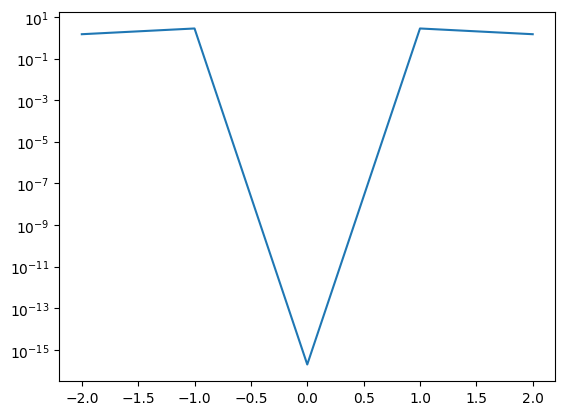

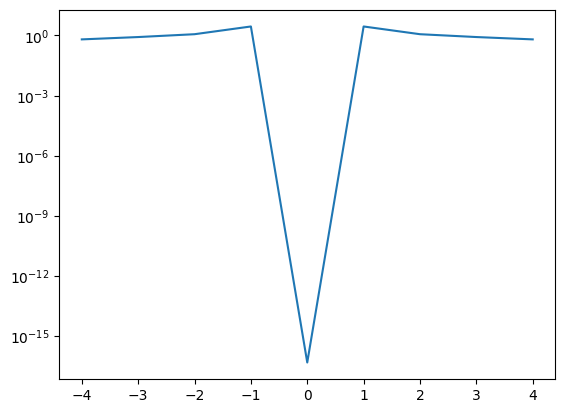

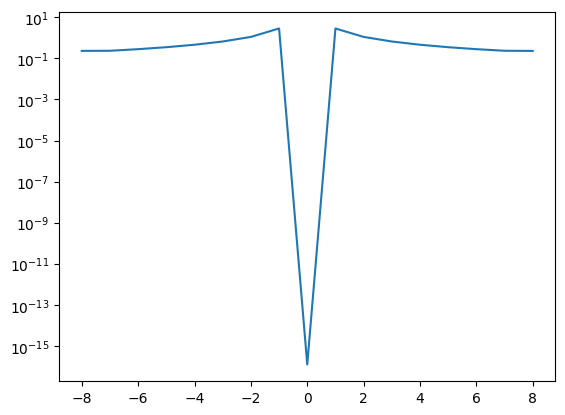

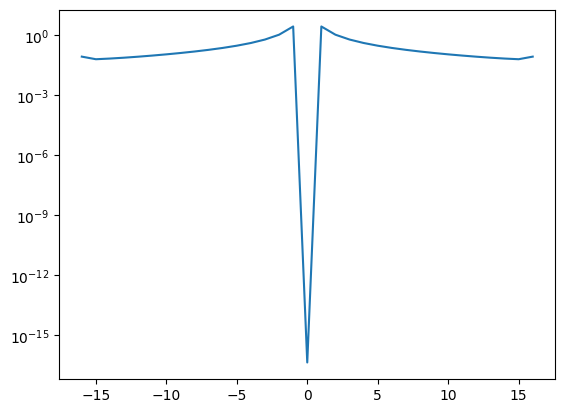

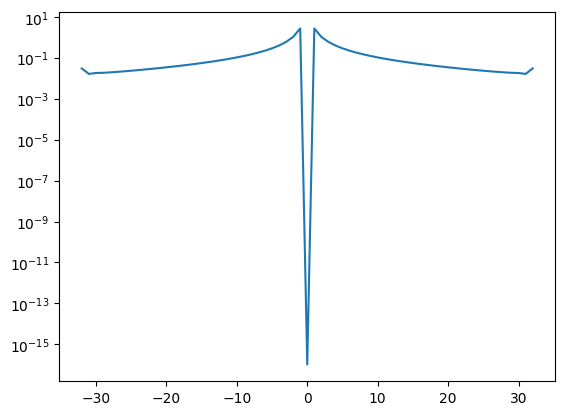

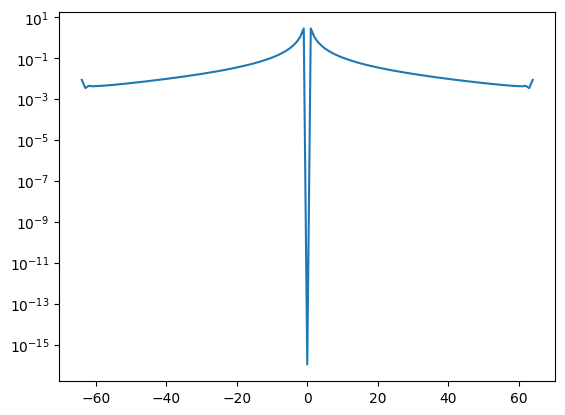

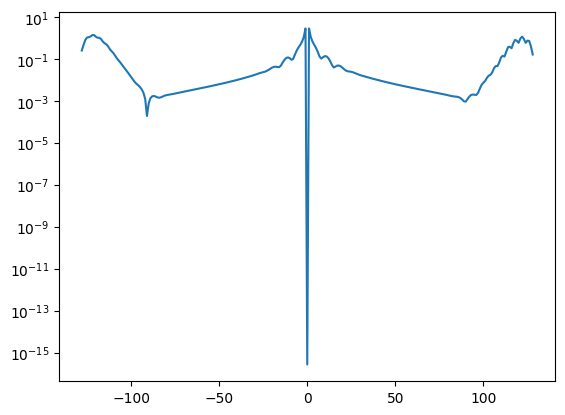

/tmp/ipykernel_10235/1889420026.py:176: RuntimeWarning: overflow encountered in multiply
  w_real = -IFFT(x_redef)*IFFT(x_deriv)
/usr/local/lib/python3.12/dist-packages/numpy/fft/_pocketfft.py:94: RuntimeWarning: invalid value encountered in fft
  return ufunc(a, fct, axes=[(axis,), (), (axis,)], out=out)


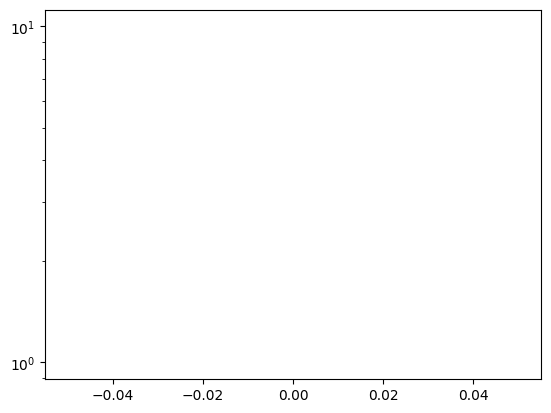

In [ ]:
M = 8

valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
H = np.zeros(M)









for i in range(M):
  temp_it = Dominio_tempo(t_i=0,t_f=0.15,k=0.15/2**i)
  espaco_it = Dominio_espaco(a=0,b = 1,h = 1/(4*(2**(i+1)) + 1))
  teste_it = Testes(ini = 5,spec = 3,dom_esp = espaco_it,dom_tem = temp_it)
  x = np.arange(espaco_it.a,espaco_it.b,espaco_it.h)

  x_ex = burger(func = RungeKutta44,tempo = temp_it,espace=espaco_it,teste = teste_it)

  H[i] = espaco_it.h

  x5 = burger(func = RK2_Exp_Explicito2,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x5_hat,k = FFT(x5)

  x5_hat = np.fft.fftshift(np.abs(x5_hat))
  k = np.fft.fftshift(k)
  plt.plot(k,x5_hat)

  plt.yscale('log')
  plt.show()





  x_ex_restruc = x_ex





  valx5[i] = erro2(x5, x_ex_restruc,espaco_it.h)











<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10235/2308582550.py:8: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Error Behavior - Burger equation - $\Delta t = 0.00001$', fontsize = 16)
/tmp/ipykernel_10235/2308582550.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta x$', fontsize = 14)


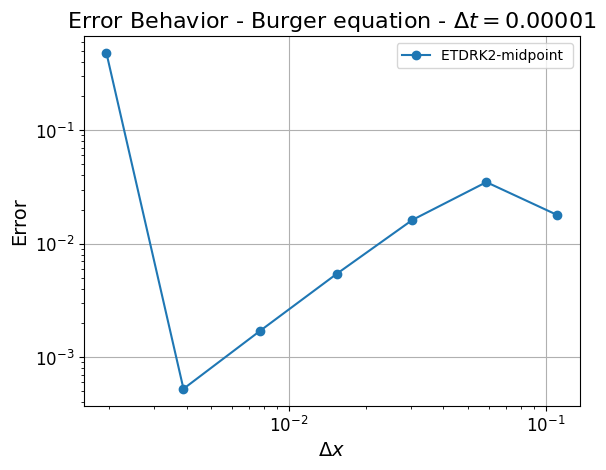

In [ ]:

plt.plot(H[:],valx5.real,'-o', label = 'ETDRK2-midpoint ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error Behavior - Burger equation - $\Delta t = 0.00001$', fontsize = 16)
plt.xlabel('$\Delta x$', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
#plt.ylim(10**(-16),10**(0))
plt.xscale('log')
plt.yscale('log')

In [ ]:
M = 8
valx1 = np.zeros(M,dtype=complex)
valx2 = np.zeros(M,dtype=complex)
valx3 = np.zeros(M,dtype=complex)
valx4 = np.zeros(M,dtype=complex)
valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
H = np.zeros(M)









for i in range(M):
  temp_it = Dominio_tempo(t_i=0,t_f=0.15,k=0.00001)
  espaco_it = Dominio_espaco(a=0,b = 1,h = 1/(4*(2**(i+1)) + 1))
  teste_it = Testes(ini = 6,spec = 3,dom_esp = espaco_it,dom_tem = temp_it)
  x = np.arange(espaco_it.a,espaco_it.b,espaco_it.h)

  x_ex = burger(func = RungeKutta44,tempo = temp_it,espace=espaco_it,teste = teste_it)

  H[i] = espaco_it.h
  x1 = burger(func = Euler_Explicito,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x2 = burger(func = RungeKutta22,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x3 = burger(func = Euler_Exp_Explicito,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x4 = burger(func = RK2_Exp_Explicito1,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x5 = burger(func = RK2_Exp_Explicito2,tempo = temp_it,espace=espaco_it,teste = teste_it)





  x_ex_restruc = x_ex



  valx1[i] = erro2(x1, x_ex_restruc,espaco_it.h)

  valx2[i] = erro2(x2, x_ex_restruc,espaco_it.h)

  valx3[i] = erro2(x3, x_ex_restruc,espaco_it.h)

  valx4[i] = erro2(x4, x_ex_restruc,espaco_it.h)

  valx5[i] = erro2(x5, x_ex_restruc,espaco_it.h)











In [ ]:
print(valx1)
print(valx2)
print(valx3)
print(valx4)
print(valx5)

print(H)

<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
<>:12: SyntaxWarning: invalid escape sequence '\D'
<>:13: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_10235/1630478910.py:12: SyntaxWarning: invalid escape sequence '\D'
  plt.title('Error Behavior - Burger equation - $\Delta t = 0.00001$', fontsize = 16)
/tmp/ipykernel_10235/1630478910.py:13: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('$\Delta x$', fontsize = 14)


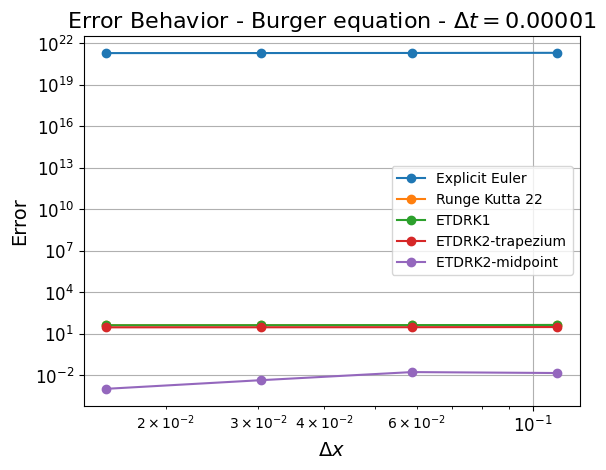

In [ ]:
plt.plot(H[:],valx1.real,'-o',label = 'Explicit Euler ')
plt.plot(H[:],valx2.real,'-o',label = 'Runge Kutta 22')
plt.plot(H[:],valx3.real,'-o',label = 'ETDRK1')
plt.plot(H[:],valx4.real,'-o',label = 'ETDRK2-trapezium')
plt.plot(H[:],valx5.real,'-o', label = 'ETDRK2-midpoint ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error Behavior - Burger equation - $\Delta t = 0.00001$', fontsize = 16)
plt.xlabel('$\Delta x$', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
#plt.ylim(10**(-16),10**(0))
plt.xscale('log')
plt.yscale('log')

In [ ]:
M = 8
valx1 = np.zeros(M,dtype=complex)
valx2 = np.zeros(M,dtype=complex)
valx3 = np.zeros(M,dtype=complex)
valx4 = np.zeros(M,dtype=complex)
valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
H1 = np.zeros(M)









for i in range(M):
  temp_it = Dominio_tempo(t_i=0,t_f=0.15,k=0.15/2**(i+5))
  espaco_it = Dominio_espaco(a=0,b = 1,h = 1/(4*(2**(4+1)) + 1))
  teste_it = Testes(ini = 6,spec = 3,dom_esp = espaco_it,dom_tem = temp_it)
  x = np.arange(espaco_it.a,espaco_it.b,espaco_it.h)

  x_ex = burger(func = RungeKutta44,tempo = temp_it,espace=espaco_it,teste = teste_it)

  H1[i] = temp_it.k
  x1 = burger(func = Euler_Explicito,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x2 = burger(func = RungeKutta22,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x3 = burger(func = Euler_Exp_Explicito,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x4 = burger(func = RK2_Exp_Explicito1,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x5 = burger(func = RK2_Exp_Explicito2,tempo = temp_it,espace=espaco_it,teste = teste_it)

  print(i)
  plt.plot(x_ex)
  plt.show()


  x_ex_restruc = x_ex



  valx1[i] = erro2(x1, x_ex_restruc,espaco_it.h)

  valx2[i] = erro2(x2, x_ex_restruc,espaco_it.h)

  valx3[i] = erro2(x3, x_ex_restruc,espaco_it.h)

  valx4[i] = erro2(x4, x_ex_restruc,espaco_it.h)

  valx5[i] = erro2(x5, x_ex_restruc,espaco_it.h)











In [ ]:
plt.plot(x5)
plt.show()

In [ ]:
plt.plot(H1[:],valx1.real,'-o',label = 'Explicit Euler ')
plt.plot(H1[:],valx2.real,'-o',label = 'Runge Kutta 22')
plt.plot(H1[:],valx3.real,'-o',label = 'ETDRK1')
plt.plot(H1[:],valx4.real,'-o',label = 'ETDRK2-trapezium')
plt.plot(H1[:],valx5.real,'-o', label = 'ETDRK2-midpoint ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error Behavior - Burger equation - $\Delta x = 1/(65)$', fontsize = 16)
plt.xlabel('$\Delta t$', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
#plt.ylim(10**(-16),10**(0))
plt.xscale('log')
plt.yscale('log')

In [ ]:
M = 8
valx1 = np.zeros(M,dtype=complex)
valx2 = np.zeros(M,dtype=complex)
valx3 = np.zeros(M,dtype=complex)
valx4 = np.zeros(M,dtype=complex)
valx5 = np.zeros(M,dtype=complex)
valex = np.zeros(M,dtype=complex)
H1 = np.zeros(M)









for i in range(M):
  temp_it = Dominio_tempo(t_i=0,t_f=0.15,k=0.15/2**(17))
  espaco_it = Dominio_espaco(a=0,b = 1,h = 1/(4*(2**(i+1)) + 1))
  teste_it = Testes(ini = 6,spec = 3,dom_esp = espaco_it,dom_tem = temp_it)
  x = np.arange(espaco_it.a,espaco_it.b,espaco_it.h)

  x_ex = burger(func = RungeKutta44,tempo = temp_it,espace=espaco_it,teste = teste_it)


  temp_it = Dominio_tempo(t_i=0,t_f=0.15,k=0.15/2**(i))
  H1[i] = temp_it.k
  x1 = burger(func = Euler_Explicito,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x2 = burger(func = RungeKutta22,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x3 = burger(func = Euler_Exp_Explicito,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x4 = burger(func = RK2_Exp_Explicito1,tempo = temp_it,espace=espaco_it,teste = teste_it)
  x5 = burger(func = RK2_Exp_Explicito2,tempo = temp_it,espace=espaco_it,teste = teste_it)


  print(i)

  x_ex_restruc = x_ex



  valx1[i] = erro2(x1, x_ex_restruc,espaco_it.h)

  valx2[i] = erro2(x2, x_ex_restruc,espaco_it.h)

  valx3[i] = erro2(x3, x_ex_restruc,espaco_it.h)

  valx4[i] = erro2(x4, x_ex_restruc,espaco_it.h)

  valx5[i] = erro2(x5, x_ex_restruc,espaco_it.h)











In [ ]:
for i in range(M):
  H1[i] = 0.15/2**(i)

In [ ]:
plt.plot(H1[:],valx1.real,'-o',label = 'Explicit Euler ')
plt.plot(H1[:],valx2.real,'-o',label = 'Runge Kutta 22')
plt.plot(H1[:],valx3.real,'-o',label = 'ETDRK1')
plt.plot(H1[:],valx4.real,'-o',label = 'ETDRK2-trapezium')
plt.plot(H1[:],valx5.real,'-o', label = 'ETDRK2-midpoint ')
#plt.plot(t,xex,label = 'Exata')
plt.legend()
plt.grid()

plt.tick_params(axis='both', which='major', labelsize=12)

plt.title('Error Behavior - Burger equation linear stiff term', fontsize = 16)
plt.xlabel('$\Delta t$', fontsize = 14)
plt.ylabel('Error', fontsize = 14)
plt.ylim(10**(-6),10**(0))
plt.xscale('log')
plt.yscale('log')